In [3]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


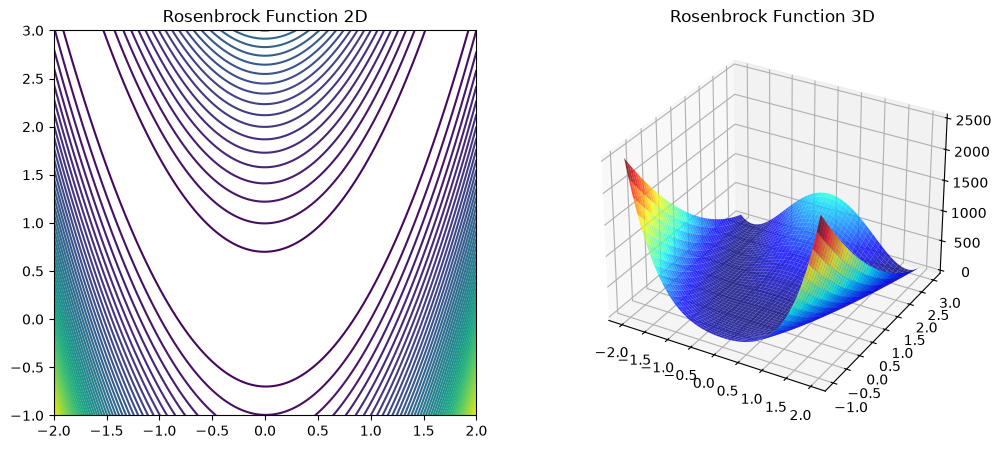

Initial guess [-1.8, 1.8], Result: [0.99999508 0.99999014], Value: 2.426114385079562e-11, Success: True, Iterations: 29, Time: 0.0111 sec
Initial guess [2.4, 3], Result: [0.99999554 0.99999106], Value: 1.9935251017332642e-11, Success: True, Iterations: 19, Time: 0.0061 sec
Initial guess [0.05, 0.005], Result: [0.9999961  0.99999218], Value: 1.523917033909588e-11, Success: True, Iterations: 21, Time: 0.0061 sec
PyGAD initial guess [-1.8, 1.8], Solution: [1.01190195 1.02462379], Value: rosenbrock(solution), iterations: 2000, Time: 1.0346 sec


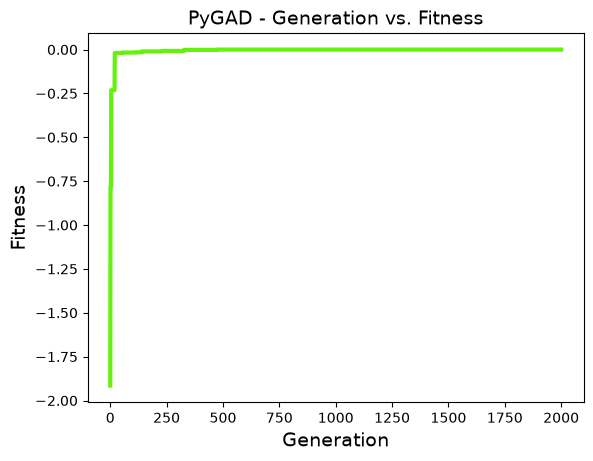

PyGAD initial guess [2.4, 3], Solution: [0.99765213 0.99557397], Value: rosenbrock(solution), iterations: 2000, Time: 1.0657 sec


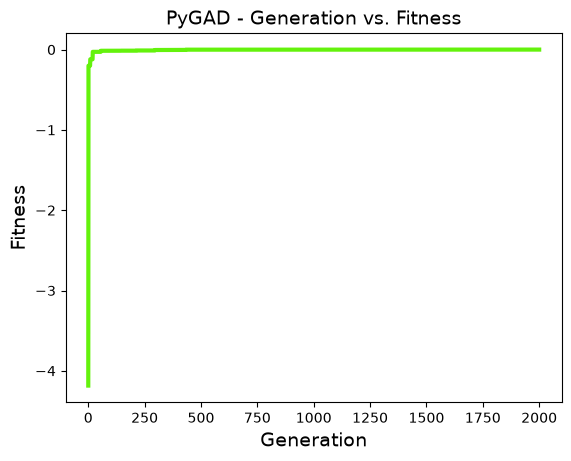

PyGAD initial guess [0.05, 0.005], Solution: [1.01527402 1.03081707], Value: rosenbrock(solution), iterations: 2000, Time: 1.1187 sec


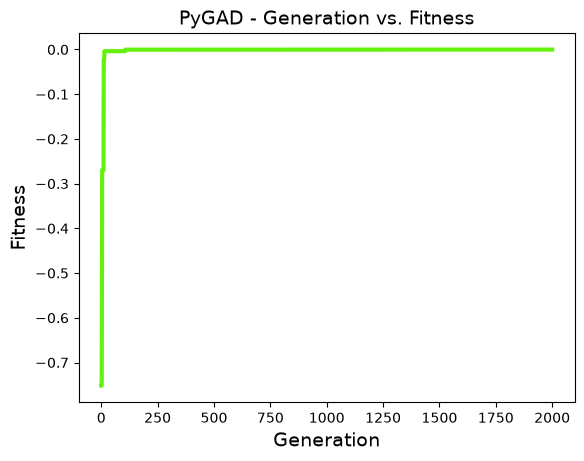

In [34]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[-1.8, 1.8], [2.4, 3], [0.05, 0.005]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: rosenbrock(solution), iterations: {iters}, Time: {elapsed_time:.4f} sec")
   
    ga_instance.plot_fitness()
    

1)Minimize fuction BFGS algorithm
2)Genetic Algorithm explain why time taken more and iterations taken more

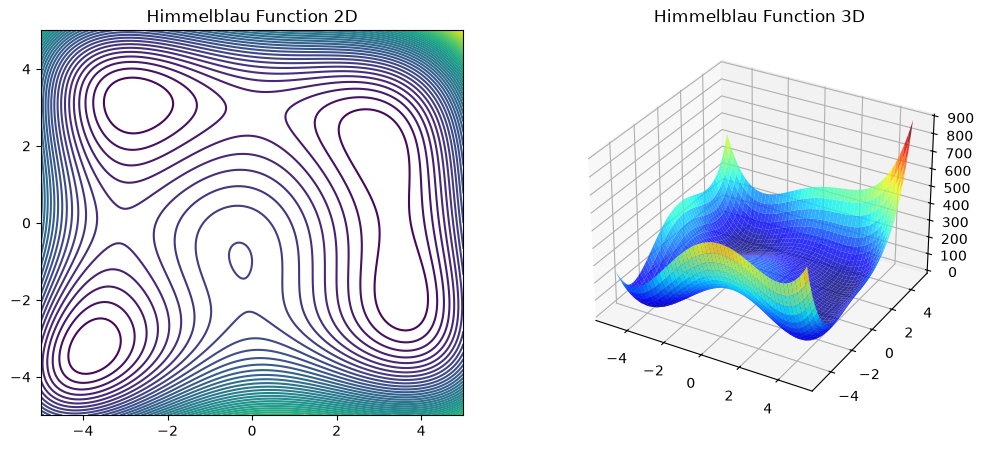

Initial guess [1, 0.005], Result: [3.         1.99999998], Value: 7.175589324611337e-15, Success: True, Iterations: 8, Time: 0.0059 sec
Initial guess [-8, 4], Result: [-2.80511811  3.13131248], Value: 7.581504637271735e-14, Success: True, Iterations: 14, Time: 0.0066 sec
Initial guess [4, 5], Result: [2.99999999 1.99999999], Value: 6.100224721467554e-15, Success: True, Iterations: 14, Time: 0.0049 sec
PyGAD initial guess [1, 0.005], Solution: [2.99884523 2.00279424], Value: 0.00011768259188737208, iterations: 2000, Time: 0.2376 sec
PyGAD initial guess [-8, 4], Solution: [ 3.59121101 -1.84924449], Value: 0.002380358861817331, iterations: 2000, Time: 0.4722 sec
PyGAD initial guess [4, 5], Solution: [3.01027247 1.99081625], Value: 0.0034580049380638343, iterations: 2000, Time: 0.7206 sec


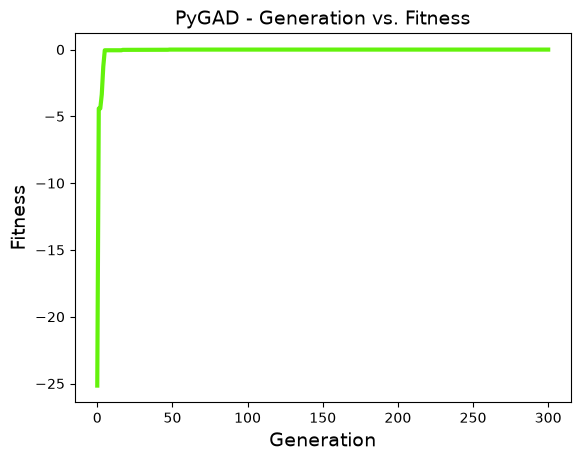

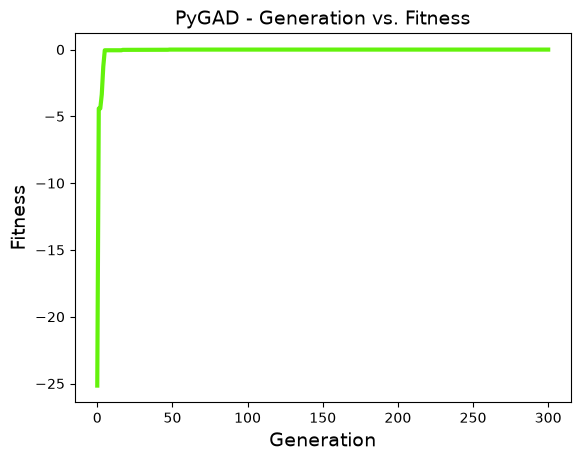

In [16]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1, 0.005], [-8, 4], [4, 5]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")


# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
for guess in init_guesses:
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec")

ga_instance.plot_fitness()

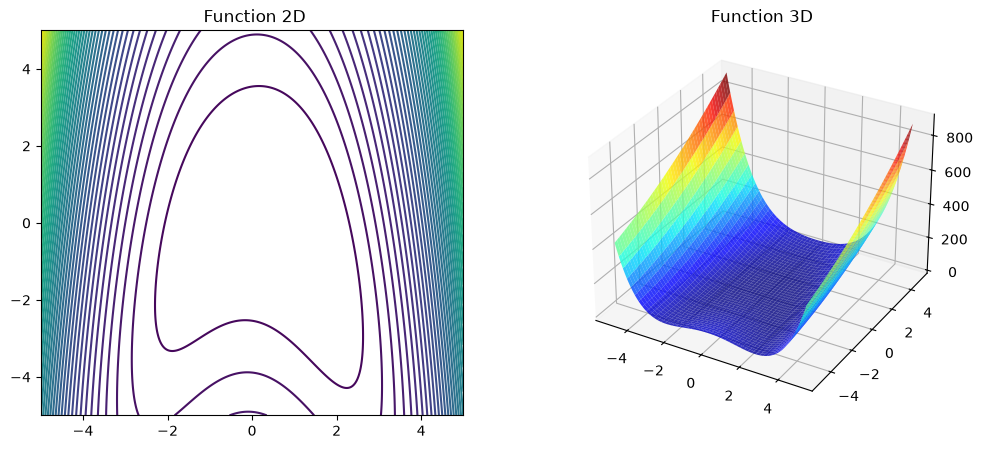

Initial guess [1, 0.005], Result: [ 9.99999994e-01 -1.81135105e-09], Value: 1.9883528909458763e-16, Success: True, Iterations: 3, Time: 0.0025 sec
Initial guess [-8, 4], Result: [9.99999856e-01 3.90701879e-07], Value: 1.8388438486189578e-13, Success: True, Iterations: 19, Time: 0.0062 sec
Initial guess [4, 5], Result: [ 1.00000128e+00 -7.42935356e-07], Value: 5.5010510447448154e-12, Success: True, Iterations: 12, Time: 0.0036 sec
PyGAD initial guess [1, 0.005], Solution: [0.98559351 0.00400536], Value: 0.0008287535878515966, iterations: 2000, Time: 0.2536 sec
PyGAD initial guess [-8, 4], Solution: [0.99481722 0.00969637], Value: 0.00012129326982585543, iterations: 2000, Time: 0.5029 sec
PyGAD initial guess [4, 5], Solution: [ 1.00662741 -0.0089619 ], Value: 0.00014304653399162758, iterations: 2000, Time: 0.7271 sec


In [15]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 1)**2 + (x[0] - 1)**2 + x[1]**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title(" Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title(" Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1, 0.005], [-8, 4], [4, 5]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")


# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
for guess in init_guesses:
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec")

# ga_instance.plot_fitness()